# Calculate Silhouette scores with bootstrapping method

Determine if there is a significant improvement in clustering after QC.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# Ignore warning about deprecated argument name in sklearn
warnings.filterwarnings("ignore", message="'force_all_finite' was renamed")

In [2]:
# Output dir for figure
output_dir = pathlib.Path("./figures")
output_dir.mkdir(exist_ok=True, parents=True)

# Output dir for HDBSCAN labels
labels_dir = pathlib.Path("./cluster_labels")
labels_dir.mkdir(exist_ok=True, parents=True)

# Load in pre- and post-QC feature selected profiles
pre_QC_df = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected_no_QC.parquet"
    )
)
post_QC_df = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected.parquet"
    )
)

# Add QC status to pre_QC_df based on matching rows in post_QC_df using metadata
# Set all rows to failing first
pre_QC_df["Metadata_QC_status"] = "failing"
# Find rows in pre_QC_df that are in post_QC_df based on metadata set to passing
metadata_cols = [
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]
# Create a MultiIndex for fast lookup
qc_index = post_QC_df.set_index(metadata_cols).index
mask = pre_QC_df.set_index(metadata_cols).index.isin(qc_index)
pre_QC_df.loc[mask, "Metadata_QC_status"] = "passing"

# Set min cluster size for HDBSCAN
min_cluster_size = 5

## Compute individual scores

### Pre-QC UMAP scores

In [3]:
# Isolate just the feature space from Metadata in dataframe
pre_X = pre_QC_df.loc[:, ~pre_QC_df.columns.str.startswith("Metadata_")].values

# Run PCA on pre-QC feature space to capture 95% of variance
pca = PCA(n_components=0.95, random_state=0)
pre_QC_pca = pca.fit_transform(pre_X)

# Run HDBSCAN using sklearn compatible interface
clusterer = HDBSCAN(min_cluster_size=min_cluster_size, n_jobs=-1)
pre_cluster_labels = clusterer.fit_predict(pre_QC_pca)

# Attach cluster labels to the original dataframe
pre_QC_df["cluster"] = pre_cluster_labels

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(pre_cluster_labels))

# Make a dataframe for enrichment analysis: only metadata + cluster label
metadata_cols = [col for col in pre_QC_df.columns if col.startswith("Metadata_")]
pre_enrichment_df = pre_QC_df[[*metadata_cols, "cluster"]].copy()

# Exclude noise points if you want enrichment only on real clusters
pre_enrichment_df = pre_enrichment_df[pre_enrichment_df["cluster"] != -1]
print(pre_enrichment_df.shape)
pre_enrichment_df.head()

Unique cluster labels (-1 is noise): [-1  0  1  2]
(7663, 21)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Metadata_ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,Metadata_QC_status,cluster
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,1,localhost230405150001,B02,3,3,8,8,f00,passing,1
8,B,2,9,failing,rejected,DMSO,816.821713,319.205179,826.262206,346.991787,...,1,localhost230405150001,B02,9,9,14,14,f00,passing,1
13,B,2,9,failing,rejected,DMSO,142.392587,475.164448,160.602327,465.429183,...,1,localhost230405150001,B02,14,14,20,20,f00,passing,1
15,B,2,9,failing,rejected,DMSO,685.212458,500.577308,707.625454,505.004406,...,1,localhost230405150001,B02,16,16,22,22,f00,passing,1
16,B,2,9,failing,rejected,DMSO,317.139394,527.677273,317.673523,468.592149,...,1,localhost230405150001,B02,17,17,23,23,f00,passing,1


### Compute Silhouette score

In [4]:
# Compute silhouette score for pre-QC clusters (excluding noise)
mask = pre_cluster_labels != -1
pre_QC_score = silhouette_score(pre_QC_pca[mask], pre_cluster_labels[mask])
print("Pre-QC Silhouette score (excluding noise):", pre_QC_score)

Pre-QC Silhouette score (excluding noise): 0.20573532800682454


### Compute enrichment score

In [5]:
# Combined cell type and treatment to make more categories
pre_enrichment_df["Metadata_cell_treatment"] = (
    pre_enrichment_df["Metadata_cell_type"]
    + "_"
    + pre_enrichment_df["Metadata_treatment"]
)

# Pick the metadata column to test for enrichment
metadata_col = "Metadata_cell_type"  # change to any categorical metadata

# contingency table: clusters x treatment
contingency = pd.crosstab(pre_enrichment_df["cluster"], pre_enrichment_df[metadata_col])

results = []
for cluster in contingency.index:
    for category in contingency.columns:
        # observed counts
        in_cluster = contingency.loc[cluster, category]
        not_in_cluster = contingency.loc[cluster, :].sum() - in_cluster

        # background counts
        in_background = contingency[category].sum() - in_cluster
        not_in_background = contingency.values.sum() - (
            in_cluster + not_in_cluster + in_background
        )

        # 2x2 table for Fisher's exact test
        table = np.array(
            [[in_cluster, not_in_cluster], [in_background, not_in_background]]
        )

        # Fisher's exact test
        odds_ratio, p_value = fisher_exact(table, alternative="greater")

        # enrichment score (log2 observed/expected)
        expected = (
            contingency[category].sum() * contingency.loc[cluster, :].sum()
        ) / contingency.values.sum()
        enrichment = np.log2((in_cluster + 1) / (expected + 1))  # +1 for stability

        results.append(
            {
                "cluster": cluster,
                "category": category,
                "observed": in_cluster,
                "expected": round(expected, 2),
                "log2_enrichment": round(enrichment, 2),
                "p_value": p_value,
            }
        )

enrichment_results = pd.DataFrame(results)
print(enrichment_results.sort_values("p_value").head(10))

   cluster category  observed  expected  log2_enrichment   p_value
3        1  healthy      1115   1110.34             0.01  0.006455
4        2  failing        17     14.53             0.21  0.068826
0        0  failing        15     12.82             0.21  0.094326
1        0  healthy         0      2.18            -1.67  1.000000
2        1  failing      6516   6520.66            -0.00  1.000000
5        2  healthy         0      2.47            -1.80  1.000000


### Post-QC UMAP scores

In [6]:
# Isolate just the feature space from Metadata in dataframe
post_X = post_QC_df.loc[:, ~post_QC_df.columns.str.startswith("Metadata_")].values

# Run PCA on post-QC feature space to capture 95% of variance
pca = PCA(n_components=0.95, random_state=0)
post_QC_pca = pca.fit_transform(post_X)

# Run HDBSCAN using sklearn compatible interface
clusterer = HDBSCAN(min_cluster_size=min_cluster_size, n_jobs=-1)
post_cluster_labels = clusterer.fit_predict(post_QC_pca)

# Attach cluster labels to the original dataframe
post_QC_df["cluster"] = post_cluster_labels

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(post_cluster_labels))

# Make a dataframe for enrichment analysis: only metadata + cluster label
metadata_cols = [col for col in post_QC_df.columns if col.startswith("Metadata_")]
post_enrichment_df = post_QC_df[[*metadata_cols, "cluster"]].copy()

# Exclude noise points if you want enrichment only on real clusters
post_enrichment_df = post_enrichment_df[post_enrichment_df["cluster"] != -1]
print(post_enrichment_df.shape)
post_enrichment_df.head()

Unique cluster labels (-1 is noise): [-1  0  1]
(20026, 20)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,cluster
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,40,1,localhost230405150001,B02,1,1,6,6,f00,0
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,40,1,localhost230405150001,B02,2,2,7,7,f00,0
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,40,1,localhost230405150001,B02,3,3,8,8,f00,0
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,40,1,localhost230405150001,B02,4,4,9,9,f00,0
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,40,1,localhost230405150001,B02,5,5,10,10,f00,0


### Compute Silhouette score

In [7]:
# Compute silhouette score for post-QC clusters (excluding noise)
mask = post_cluster_labels != -1
post_QC_score = silhouette_score(post_QC_pca[mask], post_cluster_labels[mask])
print("Post-QC Silhouette score (excluding noise):", post_QC_score)

Post-QC Silhouette score (excluding noise): 0.39106299476183476


### Compute enrichment score

In [8]:
# Combined cell type and treatment to make more categories
post_enrichment_df["Metadata_cell_treatment"] = (
    post_enrichment_df["Metadata_cell_type"]
    + "_"
    + post_enrichment_df["Metadata_treatment"]
)

# Pick the metadata column to test for enrichment
metadata_col = "Metadata_cell_type"  # change to any categorical metadata

# contingency table: clusters x treatment
contingency = pd.crosstab(
    post_enrichment_df["cluster"], post_enrichment_df[metadata_col]
)

results = []
for cluster in contingency.index:
    for category in contingency.columns:
        # observed counts
        in_cluster = contingency.loc[cluster, category]
        not_in_cluster = contingency.loc[cluster, :].sum() - in_cluster

        # background counts
        in_background = contingency[category].sum() - in_cluster
        not_in_background = contingency.values.sum() - (
            in_cluster + not_in_cluster + in_background
        )

        # 2x2 table for Fisher's exact test
        table = np.array(
            [[in_cluster, not_in_cluster], [in_background, not_in_background]]
        )

        # Fisher's exact test
        odds_ratio, p_value = fisher_exact(table, alternative="greater")

        # enrichment score (log2 observed/expected)
        expected = (
            contingency[category].sum() * contingency.loc[cluster, :].sum()
        ) / contingency.values.sum()
        enrichment = np.log2((in_cluster + 1) / (expected + 1))  # +1 for stability

        results.append(
            {
                "cluster": cluster,
                "category": category,
                "observed": in_cluster,
                "expected": round(expected, 2),
                "log2_enrichment": round(enrichment, 2),
                "p_value": p_value,
            }
        )

enrichment_results = pd.DataFrame(results)
print(enrichment_results.sort_values("p_value").head(10))

   cluster category  observed  expected  log2_enrichment   p_value
1        0  healthy      4066   4064.17             0.00  0.129643
2        1  failing         9      7.17             0.29  0.129643
0        0  failing     15951  15952.83            -0.00  1.000000
3        1  healthy         0      1.83            -1.50  1.000000


# Visualize where passing or failing cells are within each cluster

cluster
0      15
1    7631
2      17
Name: count, dtype: int64


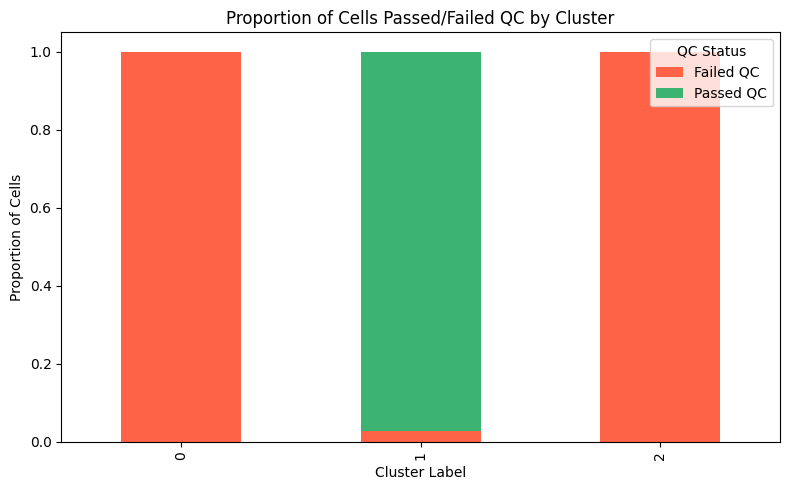

In [9]:
# Attach cluster labels to full dataframe
pre_QC_clusters_df = pre_QC_df.copy()
pre_QC_clusters_df["cluster"] = pre_cluster_labels

# Drop noise
pre_QC_clusters_df = pre_QC_clusters_df[pre_QC_clusters_df["cluster"] != -1]

# Convert labels to string for nicer plotting
pre_QC_clusters_df["cluster"] = pre_QC_clusters_df["cluster"].astype(str)

# Print number of cells in each cluster
print(pre_QC_clusters_df["cluster"].value_counts().sort_index())

# Calculate proportions for each cluster
cluster_counts = (
    pre_QC_clusters_df.groupby(["cluster", "Metadata_QC_status"])
    .size()
    .unstack(fill_value=0)
)
cluster_props = cluster_counts.div(cluster_counts.sum(axis=1), axis=0)

# Plot
ax = cluster_props.plot(
    kind="bar", stacked=True, color=["tomato", "mediumseagreen"], figsize=(8, 5)
)
ax.set_ylabel("Proportion of Cells")
ax.set_xlabel("Cluster Label")
ax.set_title("Proportion of Cells Passed/Failed QC by Cluster")
ax.legend(["Failed QC", "Passed QC"], title="QC Status")
plt.tight_layout()
plt.savefig(output_dir / "pre_QC_cluster_qc_status_proportions.png", dpi=300)
plt.show()